<a href="https://colab.research.google.com/github/AliRaddman/divar-ml-project/blob/main/notebooks/work/descriptive_ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" align="right">

# آمار توصیفی - بخش علی

در این نوت‌بوک، بخش مربوط به آمار توصیفی پروژه بررسی می‌شود.  
تمرکز فعلی روی تحلیل توزیع آگهی‌ها در دسته‌بندی‌های مختلف و سپس سؤال‌های مربوط به علی است.

</div>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

!pip install -q pyarrow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12, 6)

print("Setup completed.")

Mounted at /content/drive
Setup completed.


<div dir="rtl" align="right">

## خواندن فایل نهایی پیش‌پردازش‌شده

در این بخش، آخرین خروجی مرحله‌ی preprocessing را از Google Drive می‌خوانیم.  
این فایل شامل داده‌ی تمیزشده و ستون‌های ساخته‌شده در مراحل قبلی است.

</div>

In [2]:
data_path = "/content/drive/MyDrive/divar_project/cleaned_step3_geo.parquet"

df = pd.read_parquet(data_path)

print("Data loaded.")
print("Shape:", df.shape)
print("Number of columns:", len(df.columns))

df.head()

Data loaded.
Shape: (999943, 85)
Number of columns: 85


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,location_latitude,location_longitude,location_radius,created_at_shamsi,created_at_shamsi_readable,construction_year_was_missing,construction_year_imputed,transaction_type,price_value_pos,rent_value_pos,credit_value_pos,building_size_pos,land_size_pos,area_for_unit_price,monthly_rent_equivalent,credit_equivalent,sale_price_per_m2,monthly_rent_equivalent_per_m2,credit_equivalent_per_m2,target_price,target_price_type,target_price_per_m2,is_valid_area_basic,is_valid_sale_price_basic,is_valid_rent_value_basic,is_valid_credit_value_basic,is_valid_target_price_basic,is_valid_area_q01_q99_by_cat3,is_valid_target_price_per_m2_q01_q99_by_cat3,is_valid_for_price_analysis,has_geo,is_valid_geo_basic,is_valid_geo_for_analysis,utm_easting,utm_northing,utm_zone_number,utm_zone_letter
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,500.0,NaN,<NA>,NaN,3.0,NaN,NaN,False,False,False,False,NaN,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,4.0,35.811684,50.936600,500.0,1403-05,مرداد 1403,True,1395.0,temporary_rent,NaN,NaN,NaN,500.0,NaN,500.0,NaN,NaN,NaN,NaN,NaN,NaN,not_defined,NaN,True,True,True,True,True,True,<NA>,False,True,True,True,494272.329998,3.963064e+06,39,S
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,60.0,NaN,<NA>,3.0,1.0,NaN,NaN,False,True,True,True,1384.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,NaN,NaN,500.0,1403-02,اردیبهشت 1403,False,1384.0,sell,8.500000e+09,NaN,NaN,60.0,NaN,60.0,NaN,NaN,1.416667e+08,NaN,NaN,8.500000e+09,sale_total_price,1.416667e+08,True,True,True,True,True,True,True,True,False,<NA>,False,NaN,NaN,<NA>,<NA>
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,NaN,NaN,NaN,مقطوع,750000000.0,False,False,750000000.0,NaN,26000000.0,NaN,NaN,132.0,NaN,<NA>,3.0,3.0,NaN,NaN,False,True,True,True,1401.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,35.703865,51.373459,NaN,1403-07,مهر 1403,False,1401.0,rent,NaN,26000000.0,750000000.0,132.0,NaN,132.0,48500000.0,1.616667e+09,NaN,3.674242e+05,1.224747e+07,4.850000e+07,monthly_rent_equivalent,3.674242e+05,True,True,True,True,True,True,True,True,True,True,True,533784.424602,3.951168e+06,39,S
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,NaN,NaN,NaN,مقطوع,950000000.0,False,False,950000000.0,NaN,95000000.0,NaN,NaN,90.0,NaN,<NA>,4.0,1.0,NaN,NaN,False,True,False,True,1400.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,1403-03,خرداد 1403,False,1400.0,rent,NaN,95000000.0,950000000.0,90.0,NaN,90.0,123500000.0,4.116667e+09,NaN,1.372222e+06,4.574074e+07,1.235000e+08,monthly_rent_equivalent,1.372222e+06,True,True,True,True,True,True,True,True,False,<NA>,False,NaN,NaN,<NA>,<NA>
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱

<div dir="rtl" align="right">

## بررسی ستون‌های دسته‌بندی

در سؤال اول آمار توصیفی، باید توزیع آگهی‌ها را بر اساس دسته‌بندی سطح دو و سطح سه بررسی کنیم.  
برای این کار ابتدا وضعیت ستون‌های زیر را چک می‌کنیم:

`cat2_slug`

`cat3_slug`

</div>

In [3]:
category_cols = ["cat2_slug", "cat3_slug"]

print("Missing values:")
print(df[category_cols].isna().sum())

print("\nUnique values:")
print(df[category_cols].nunique())

print("\ncat2_slug values:")
print(df["cat2_slug"].value_counts())

print("\nTop 20 cat3_slug values:")
print(df["cat3_slug"].value_counts().head(20))

Missing values:
cat2_slug    0
cat3_slug    0
dtype: int64

Unique values:
cat2_slug     6
cat3_slug    16
dtype: int64

cat2_slug values:
cat2_slug
residential-sell        558692
residential-rent        276528
commercial-rent          76564
commercial-sell          38860
temporary-rent           29897
real-estate-services     19402
Name: count, dtype: int64

Top 20 cat3_slug values:
cat3_slug
apartment-sell                        303372
apartment-rent                        211853
plot-old                              133570
house-villa-sell                      121750
house-villa-rent                       64675
shop-rent                              45993
shop-sell                              21855
office-rent                            21416
suite-apartment                        16460
presell                                15780
villa                                  12898
industry-agriculture-business-sell     11850
industry-agriculture-business-rent      9155
office-sell       

<div dir="rtl" align="right">

## محاسبه تعداد و درصد آگهی‌ها در هر دسته

در این بخش، تعداد آگهی‌های هر دسته را برای دسته‌بندی سطح دو و سطح سه محاسبه می‌کنیم.  
علاوه بر تعداد، درصد سهم هر دسته از کل داده‌ها نیز محاسبه می‌شود تا مقایسه دسته‌ها راحت‌تر باشد.

</div>

In [4]:
def category_distribution(data, column_name):
    counts = data[column_name].value_counts()
    percents = data[column_name].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        column_name: counts.index,
        "count": counts.values,
        "percent": percents.values
    })

    result["percent"] = result["percent"].round(2)

    return result


cat2_distribution = category_distribution(df, "cat2_slug")
cat3_distribution = category_distribution(df, "cat3_slug")

print("cat2_slug distribution:")
display(cat2_distribution)

print("\ncat3_slug distribution:")
display(cat3_distribution)

cat2_slug distribution:


,cat2_slug,count,percent
0,residential-sell,558692,55.87
1,residential-rent,276528,27.65
2,commercial-rent,76564,7.66
3,commercial-sell,38860,3.89
4,temporary-rent,29897,2.99
5,real-estate-services,19402,1.94



cat3_slug distribution:


,cat3_slug,count,percent
0,apartment-sell,303372,30.34
1,apartment-rent,211853,21.19
2,plot-old,133570,13.36
3,house-villa-sell,121750,12.18
4,house-villa-rent,64675,6.47
5,shop-rent,45993,4.60
6,shop-sell,21855,2.19
7,office-rent,21416,2.14
8,suite-apartment,16460,1.65
9,presell,15780,1.58


<div dir="rtl" align="right">

## نمودار توزیع آگهی‌ها بر اساس دسته‌بندی سطح دو

در این بخش، تعداد آگهی‌ها را در هر مقدار از ستون `cat2_slug` رسم می‌کنیم.  
این نمودار نشان می‌دهد داده بیشتر از چه نوع آگهی‌هایی تشکیل شده است.

</div>

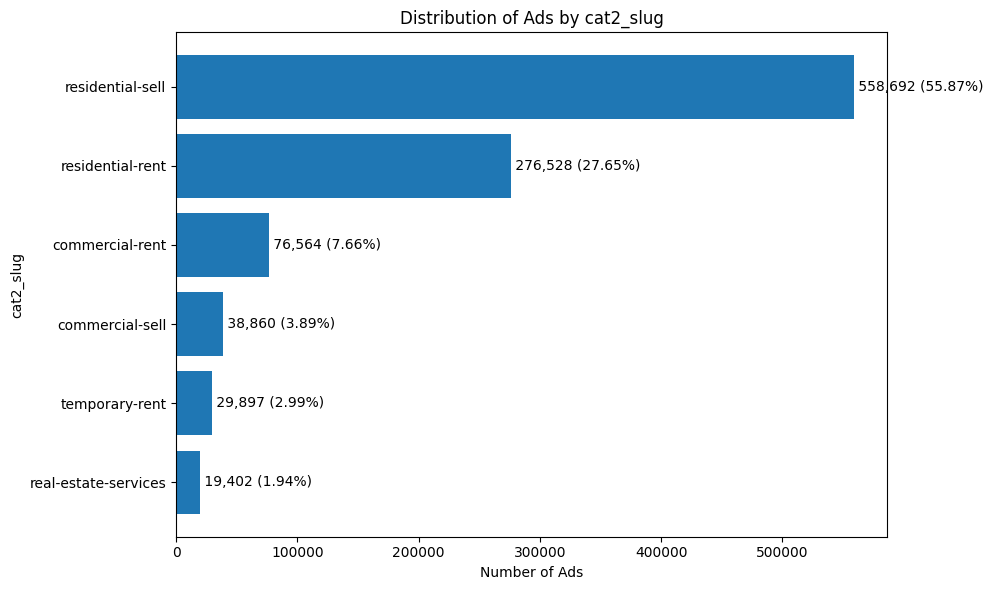

In [5]:
cat2_plot_data = cat2_distribution.sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(cat2_plot_data["cat2_slug"], cat2_plot_data["count"])

plt.title("Distribution of Ads by cat2_slug")
plt.xlabel("Number of Ads")
plt.ylabel("cat2_slug")

for index, row in cat2_plot_data.iterrows():
    plt.text(
        row["count"],
        row["cat2_slug"],
        f' {row["count"]:,} ({row["percent"]}%)',
        va="center"
    )

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نمودار توزیع آگهی‌ها بر اساس دسته‌بندی سطح سه

در این بخش، تعداد آگهی‌ها را در هر مقدار از ستون `cat3_slug` رسم می‌کنیم.  
چون تعداد دسته‌های سطح سه فقط `16` مورد است، همه‌ی دسته‌ها را در نمودار نمایش می‌دهیم.

</div>

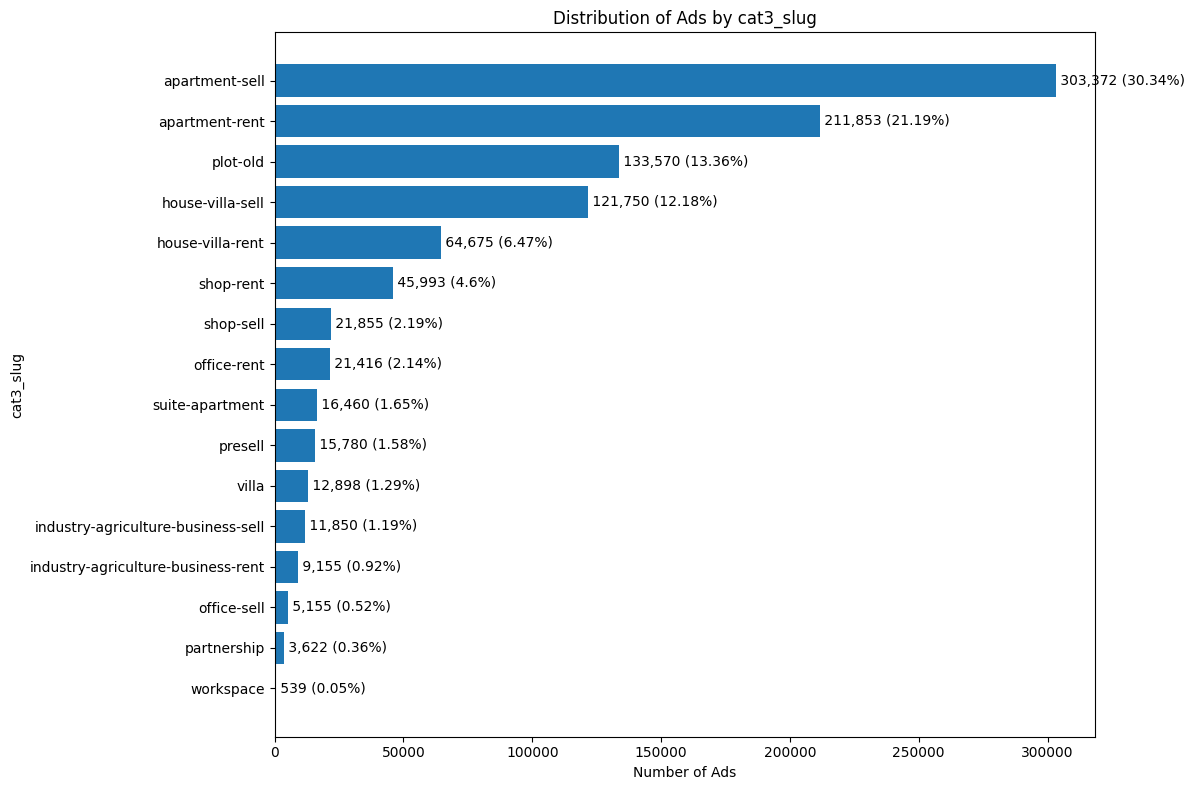

In [6]:
cat3_plot_data = cat3_distribution.sort_values("count", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(cat3_plot_data["cat3_slug"], cat3_plot_data["count"])

plt.title("Distribution of Ads by cat3_slug")
plt.xlabel("Number of Ads")
plt.ylabel("cat3_slug")

for index, row in cat3_plot_data.iterrows():
    plt.text(
        row["count"],
        row["cat3_slug"],
        f' {row["count"]:,} ({row["percent"]}%)',
        va="center"
    )

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

### تحلیل توزیع آگهی‌ها در دسته‌بندی‌ها

در دسته‌بندی سطح دو، بیشترین تعداد آگهی‌ها مربوط به دسته‌ی

`residential-sell`

است که حدود

`55.87%`

از کل داده‌ها را تشکیل می‌دهد. بعد از آن دسته‌ی

`residential-rent`

با حدود

`27.65%`

قرار دارد. بنابراین بخش عمده‌ی دیتاست مربوط به آگهی‌های مسکونی، مخصوصاً فروش مسکونی است.

در دسته‌بندی سطح سه نیز بیشترین سهم مربوط به

`apartment-sell`

با حدود

`30.34%`

و سپس

`apartment-rent`

با حدود

`21.19%`

است. این موضوع نشان می‌دهد که آگهی‌های آپارتمان، چه برای فروش و چه برای اجاره، بخش غالب دیتاست را تشکیل می‌دهند.

همچنین دسته‌هایی مثل

`workspace`

و

`partnership`

سهم بسیار کمی از داده دارند. بنابراین در تحلیل‌های بعدی و مخصوصاً مدل‌سازی، باید به نامتوازن بودن توزیع دسته‌ها توجه شود؛ زیرا نتایج کلی ممکن است بیشتر تحت تأثیر دسته‌های پرتعداد مثل آپارتمان فروش و آپارتمان اجاره قرار بگیرد.

</div>

<div dir="rtl" align="right">

## سؤال ۲: بررسی آماده بودن داده برای تحلیل سال ساخت

قبل از رسم هیستوگرام سال ساخت، بررسی می‌کنیم فایل نهایی preprocessing نسخه‌ی اصلاح‌شده باشد.  
در نسخه‌ی اصلاح‌شده، ستون اصلی `construction_year` مقدارهای گم‌شده را حفظ می‌کند و دو ستون کمکی برای مدل‌سازی ساخته شده‌اند.

</div>

In [7]:
data_path = "/content/drive/MyDrive/divar_project/cleaned_step3_geo.parquet"

df = pd.read_parquet(data_path)

check_cols = [
    "construction_year",
    "construction_year_was_missing",
    "construction_year_imputed",
]

print("Shape:", df.shape)

print("\nExisting check columns:")
print([col for col in check_cols if col in df.columns])

print("\nMissing check columns:")
print([col for col in check_cols if col not in df.columns])

print("\nMissing values:")
existing_cols = [col for col in check_cols if col in df.columns]
print(df[existing_cols].isna().sum())

Shape: (999943, 85)

Existing check columns:
['construction_year', 'construction_year_was_missing', 'construction_year_imputed']

Missing check columns:
[]

Missing values:
construction_year                184164
construction_year_was_missing         0
construction_year_imputed             0
dtype: int64


<div dir="rtl" align="right">

## رسم هیستوگرام سال ساخت

در این بخش، توزیع سال ساخت املاک را رسم می‌کنیم.  
برای جلوگیری از ایجاد الگوی مصنوعی، از ستون اصلی `construction_year` استفاده می‌کنیم و مقدارهای گم‌شده را در رسم هیستوگرام کنار می‌گذاریم.

</div>

Number of rows used in histogram:
815779

Number of missing construction_year values excluded:
184164


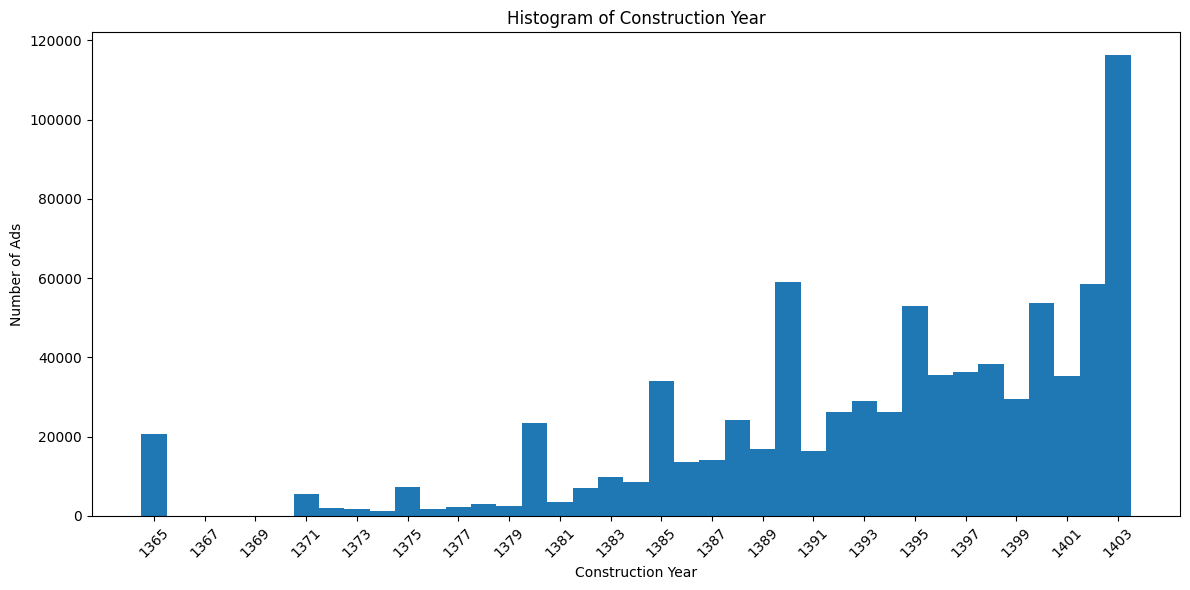

In [8]:
construction_year_data = df["construction_year"].dropna().astype(int)

print("Number of rows used in histogram:")
print(len(construction_year_data))

print("\nNumber of missing construction_year values excluded:")
print(df["construction_year"].isna().sum())

plt.figure(figsize=(12, 6))

bins = np.arange(
    construction_year_data.min(),
    construction_year_data.max() + 2
) - 0.5

plt.hist(construction_year_data, bins=bins)

plt.title("Histogram of Construction Year")
plt.xlabel("Construction Year")
plt.ylabel("Number of Ads")

plt.xticks(
    np.arange(construction_year_data.min(), construction_year_data.max() + 1, 2),
    rotation=45
)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## خلاصه عددی سال‌های پرتکرار

برای تفسیر بهتر هیستوگرام، پرتکرارترین سال‌های ساخت را به‌صورت جدولی بررسی می‌کنیم.  
این جدول کمک می‌کند مشخص شود کدام سال‌های ساخت بیشترین سهم را در داده‌های دارای مقدار معتبر دارند.

</div>

In [9]:
top_construction_years = (
    construction_year_data
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_construction_years.columns = ["construction_year", "count"]

top_construction_years["percent"] = (
    top_construction_years["count"] / len(construction_year_data) * 100
).round(2)

display(top_construction_years)

,construction_year,count,percent
0,1403,116247,14.25
1,1390,59136,7.25
2,1402,58422,7.16
3,1400,53671,6.58
4,1395,53027,6.50
5,1398,38206,4.68
6,1397,36324,4.45
7,1396,35487,4.35
8,1401,35327,4.33
9,1385,34063,4.18


<div dir="rtl" align="right">

## بررسی جهش سال ۱۳۹۰

برای بررسی دلیل فراوانی بالای سال `1390`، بررسی می‌کنیم این مقدار بیشتر در کدام دسته‌های سطح سه دیده می‌شود.  
اگر بیشتر در چند دسته‌ی خاص متمرکز باشد، تحلیل آن دقیق‌تر خواهد بود.

</div>

In [10]:
year_1390_by_cat3 = (
    df[df["construction_year"] == 1390]
    .groupby("cat3_slug")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count_1390")
)

year_total_by_cat3 = (
    df[df["construction_year"].notna()]
    .groupby("cat3_slug")
    .size()
    .reset_index(name="total_with_year")
)

year_1390_analysis = year_1390_by_cat3.merge(
    year_total_by_cat3,
    on="cat3_slug",
    how="left"
)

year_1390_analysis["percent_1390_in_cat3"] = (
    year_1390_analysis["count_1390"] / year_1390_analysis["total_with_year"] * 100
).round(2)

display(year_1390_analysis)

/tmp/ipykernel_452/3043503711.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cat3_slug")
/tmp/ipykernel_452/3043503711.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cat3_slug")


,cat3_slug,count_1390,total_with_year,percent_1390_in_cat3
0,apartment-rent,18383,211840,8.68
1,apartment-sell,16255,303367,5.36
2,house-villa-rent,7828,64664,12.11
3,house-villa-sell,6460,121735,5.31
4,shop-rent,4776,45963,10.39
5,office-rent,2110,21346,9.88
6,shop-sell,1714,21844,7.85
7,industry-agriculture-business-rent,684,8677,7.88
8,industry-agriculture-business-sell,559,11187,5.00
9,office-sell,367,5155,7.12


<div dir="rtl" align="right">

### بررسی جهش سال ساخت ۱۳۹۰

برای بررسی فراوانی بالای سال `1390`، توزیع این سال در دسته‌بندی‌های سطح سه بررسی شد. نتیجه نشان داد که این مقدار فقط در یک دسته خاص متمرکز نیست و در چند دسته‌ی پرتعداد مانند `apartment-rent`، `apartment-sell`، `house-villa-rent` و `house-villa-sell` دیده می‌شود.

از نظر درصدی، سهم سال `1390` در برخی دسته‌های اجاره‌ای مانند `house-villa-rent`، `shop-rent` و `office-rent` بیشتر است. بنابراین این جهش می‌تواند هم ناشی از وجود واقعی تعداد زیادی ملک ساخته‌شده در ابتدای دهه ۱۳۹۰ باشد و هم تا حدی به دلیل وارد کردن تقریبی یا گرد شده‌ی سال ساخت توسط آگهی‌دهنده‌ها رخ داده باشد.

</div>

<div dir="rtl" align="right">

### جمع‌بندی سؤال ۲

در این سؤال، توزیع سال ساخت املاک با استفاده از ستون `construction_year` بررسی شد. برای جلوگیری از ایجاد الگوی مصنوعی، مقدارهای گم‌شده‌ی این ستون در رسم هیستوگرام پر نشدند و فقط ردیف‌هایی که سال ساخت معتبر داشتند وارد تحلیل شدند.

هیستوگرام نشان می‌دهد که بخش قابل توجهی از آگهی‌ها مربوط به املاک نسبتاً جدید است. بیشترین فراوانی مربوط به سال `1403` است که حدود `14.25%` از داده‌های دارای سال ساخت معتبر را تشکیل می‌دهد.

همچنین سال `1390` نیز فراوانی نسبتاً بالایی دارد. بررسی دقیق‌تر نشان داد که این مقدار فقط در یک دسته‌ی خاص متمرکز نیست و در چند دسته‌ی اصلی مانند `apartment-rent`، `apartment-sell`، `house-villa-rent` و `house-villa-sell` دیده می‌شود. بنابراین این جهش می‌تواند ترکیبی از واقعیت بازار و ورود تقریبی سال ساخت توسط کاربران باشد.

</div>

<div dir="rtl" align="right">

## سؤال ۳: بررسی ستون‌های زمانی و نوع معامله

در این سؤال، می‌خواهیم تعداد آگهی‌های فروش و اجاره را در ماه‌های مختلف بررسی کنیم.  
برای این کار ابتدا وضعیت ستون‌های مربوط به تاریخ شمسی و نوع معامله را چک می‌کنیم.

</div>

In [11]:
question3_cols = [
    "created_at_shamsi",
    "created_at_shamsi_readable",
    "transaction_type",
]

print("Missing values:")
print(df[question3_cols].isna().sum())

print("\nUnique transaction_type values:")
print(df["transaction_type"].value_counts(dropna=False))

print("\nMonth range:")
print("min:", df["created_at_shamsi"].min())
print("max:", df["created_at_shamsi"].max())

print("\nReadable months:")
print(df["created_at_shamsi_readable"].value_counts().sort_index())

Missing values:
created_at_shamsi             0
created_at_shamsi_readable    0
transaction_type              0
dtype: int64

Unique transaction_type values:
transaction_type
sell              597552
rent              353092
temporary_rent     29897
other              19402
Name: count, dtype: int64

Month range:
min: 1398-11
max: 1403-12

Readable months:
created_at_shamsi_readable
آبان 1400             1
آبان 1401             9
آبان 1402           353
آبان 1403        121432
آذر 1399              1
آذر 1400              2
آذر 1401             11
آذر 1402            532
آذر 1403         116439
اردیبهشت 1400         1
اردیبهشت 1401         7
اردیبهشت 1402        53
اردیبهشت 1403    108758
اسفند 1400            1
اسفند 1401           25
اسفند 1402         1881
اسفند 1403            5
بهمن 1398             1
بهمن 1399             1
بهمن 1400             2
بهمن 1401            17
بهمن 1402          1211
بهمن 1403           148
تیر 1401              4
تیر 1402             96
تیر 1403      

<div dir="rtl" align="right">

## محاسبه تعداد آگهی‌های فروش و اجاره در هر ماه

در این بخش، فقط آگهی‌های `sell` و `rent` را نگه می‌داریم و تعداد آن‌ها را برای هر ماه شمسی محاسبه می‌کنیم.  
مرتب‌سازی ماه‌ها بر اساس ستون `created_at_shamsi` انجام می‌شود، نه متن خوانای ماه.

</div>

In [12]:
q3_df = df[df["transaction_type"].isin(["sell", "rent"])].copy()

monthly_counts = (
    q3_df
    .groupby(
        ["created_at_shamsi", "created_at_shamsi_readable", "transaction_type"],
        observed=True
    )
    .size()
    .reset_index(name="ads_count")
)

monthly_counts_pivot = (
    monthly_counts
    .pivot_table(
        index=["created_at_shamsi", "created_at_shamsi_readable"],
        columns="transaction_type",
        values="ads_count",
        fill_value=0
    )
    .reset_index()
)

monthly_counts_pivot.columns.name = None

# اگر در بعضی حالت‌ها یکی از ستون‌ها ساخته نشد، مقدار آن را صفر می‌گذاریم
for col in ["sell", "rent"]:
    if col not in monthly_counts_pivot.columns:
        monthly_counts_pivot[col] = 0

monthly_counts_pivot["total_sell_rent"] = (
    monthly_counts_pivot["sell"] + monthly_counts_pivot["rent"]
)

monthly_counts_pivot = monthly_counts_pivot.sort_values("created_at_shamsi")

display(monthly_counts_pivot)

,created_at_shamsi,created_at_shamsi_readable,rent,sell,total_sell_rent
0,1398-11,بهمن 1398,0.0,1.0,1.0
1,1399-11,بهمن 1399,0.0,1.0,1.0
2,1400-02,اردیبهشت 1400,0.0,1.0,1.0
3,1400-03,خرداد 1400,0.0,1.0,1.0
4,1400-08,آبان 1400,0.0,1.0,1.0
5,1400-09,آذر 1400,1.0,1.0,2.0
6,1400-10,دی 1400,0.0,1.0,1.0
7,1400-11,بهمن 1400,0.0,1.0,1.0
8,1401-01,فروردین 1401,0.0,2.0,2.0
9,1401-02,اردیبهشت 1401,0.0,2.0,2.0


<div dir="rtl" align="right">

## نمودار کامل تعداد آگهی‌های فروش و اجاره در همه ماه‌ها

در این نمودار، همه‌ی ماه‌های موجود در دیتاست نمایش داده می‌شوند.  
هدف این است که ابتدا تصویر کامل داده را ببینیم و سپس درباره‌ی بازه‌ی قابل اتکاتر برای تحلیل تصمیم بگیریم.

</div>

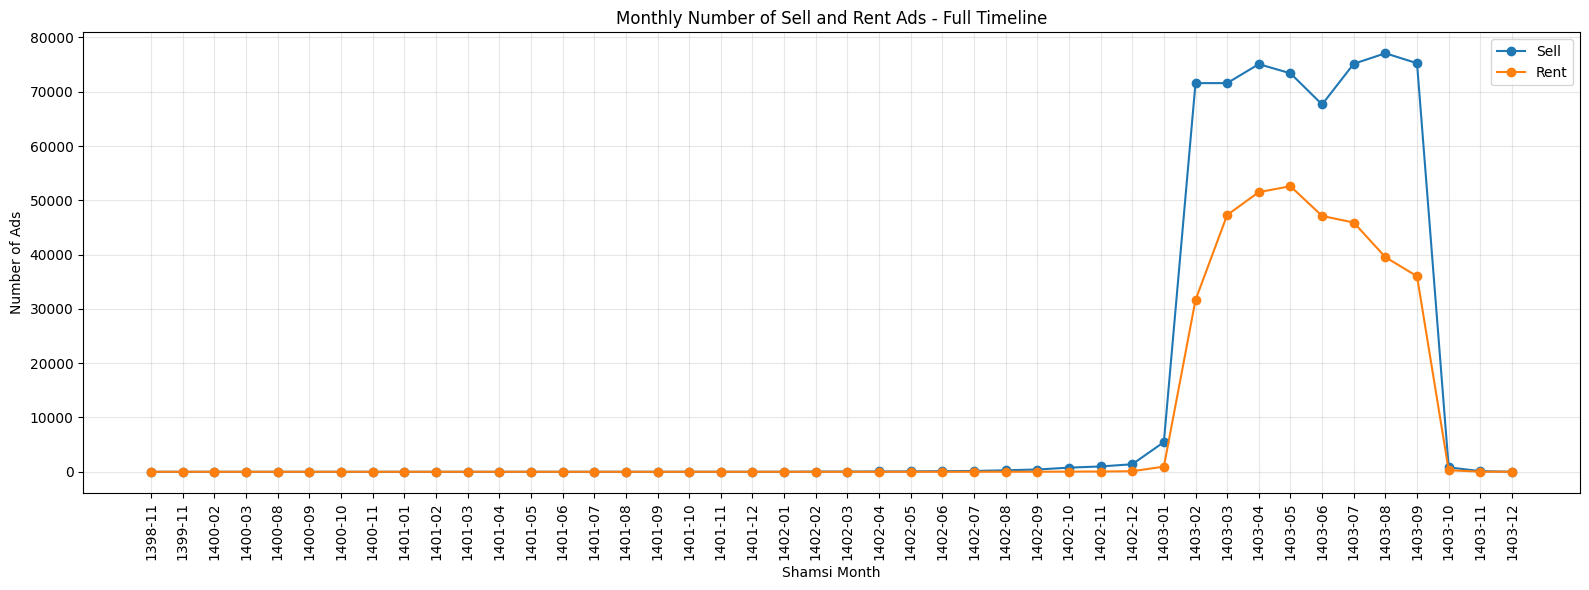

In [16]:
plt.figure(figsize=(16, 6))

plt.plot(
    monthly_counts_pivot["created_at_shamsi"],
    monthly_counts_pivot["sell"],
    marker="o",
    label="Sell"
)

plt.plot(
    monthly_counts_pivot["created_at_shamsi"],
    monthly_counts_pivot["rent"],
    marker="o",
    label="Rent"
)

plt.title("Monthly Number of Sell and Rent Ads - Full Timeline")
plt.xlabel("Shamsi Month")
plt.ylabel("Number of Ads")
plt.xticks(rotation=90)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نمودار روند آگهی‌های فروش و اجاره در بازه‌ی قابل اتکا

نمودار کامل نشان داد که بیشتر داده‌ها در بازه‌ی `1403-02` تا `1403-09` قرار دارند.  
بنابراین برای تحلیل دقیق‌تر روند فروش و اجاره، فقط ماه‌هایی بررسی می‌شوند که تعداد کل آگهی‌های فروش و اجاره در آن‌ها حداقل `10000` مورد باشد.

</div>

,created_at_shamsi,created_at_shamsi_readable,sell,rent,total_sell_rent
33,1403-02,اردیبهشت 1403,71580.0,31633.0,103213.0
34,1403-03,خرداد 1403,71582.0,47294.0,118876.0
35,1403-04,تیر 1403,75077.0,51502.0,126579.0
36,1403-05,مرداد 1403,73392.0,52596.0,125988.0
37,1403-06,شهریور 1403,67651.0,47119.0,114770.0
38,1403-07,مهر 1403,75144.0,45902.0,121046.0
39,1403-08,آبان 1403,77081.0,39535.0,116616.0
40,1403-09,آذر 1403,75246.0,36012.0,111258.0


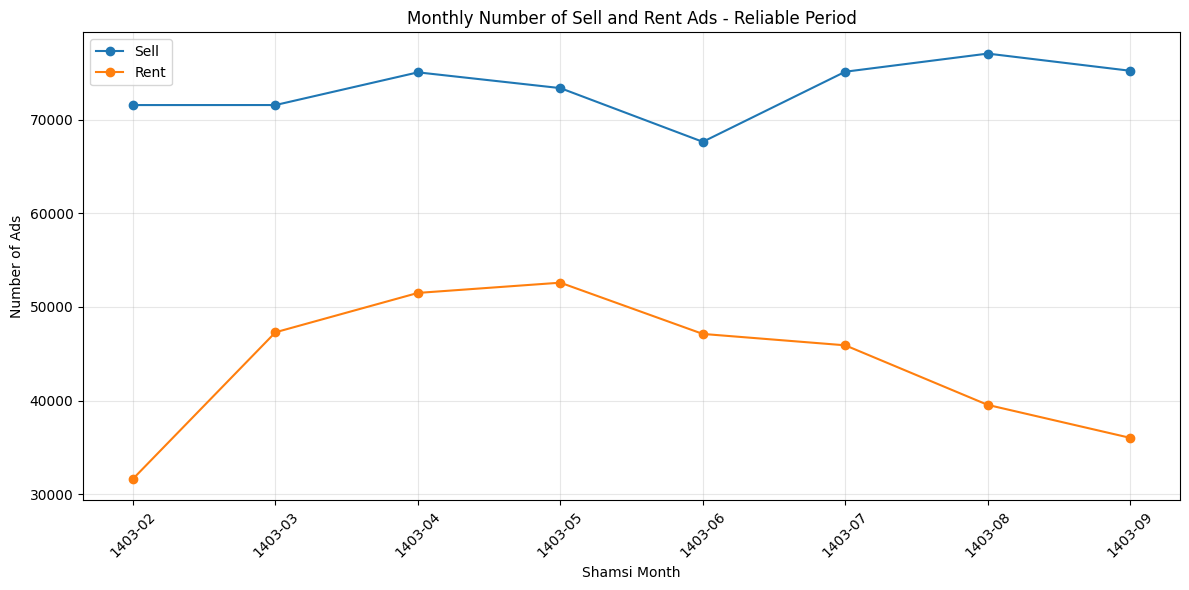

In [17]:
q3_reliable_data = monthly_counts_pivot[
    monthly_counts_pivot["total_sell_rent"] >= 10000
].copy()

display(q3_reliable_data[[
    "created_at_shamsi",
    "created_at_shamsi_readable",
    "sell",
    "rent",
    "total_sell_rent"
]])

plt.figure(figsize=(12, 6))

plt.plot(
    q3_reliable_data["created_at_shamsi"],
    q3_reliable_data["sell"],
    marker="o",
    label="Sell"
)

plt.plot(
    q3_reliable_data["created_at_shamsi"],
    q3_reliable_data["rent"],
    marker="o",
    label="Rent"
)

plt.title("Monthly Number of Sell and Rent Ads - Reliable Period")
plt.xlabel("Shamsi Month")
plt.ylabel("Number of Ads")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## بررسی تغییرات ماه‌به‌ماه فروش و اجاره

برای پاسخ دقیق‌تر به این بخش از سؤال که آیا تعداد آگهی‌ها در ماه‌های خاصی افزایش چشم‌گیر داشته است یا نه، تغییرات ماه‌به‌ماه تعداد آگهی‌های فروش و اجاره را محاسبه می‌کنیم.

</div>

In [18]:
q3_change_analysis = q3_reliable_data[[
    "created_at_shamsi",
    "created_at_shamsi_readable",
    "sell",
    "rent"
]].copy()

# محاسبه تغییر مطلق نسبت به ماه قبل
q3_change_analysis["sell_change"] = q3_change_analysis["sell"].diff()
q3_change_analysis["rent_change"] = q3_change_analysis["rent"].diff()

# محاسبه درصد تغییر نسبت به ماه قبل
q3_change_analysis["sell_change_percent"] = (
    q3_change_analysis["sell"].pct_change() * 100
).round(2)

q3_change_analysis["rent_change_percent"] = (
    q3_change_analysis["rent"].pct_change() * 100
).round(2)

display(q3_change_analysis)

,created_at_shamsi,created_at_shamsi_readable,sell,rent,sell_change,rent_change,sell_change_percent,rent_change_percent
33,1403-02,اردیبهشت 1403,71580.0,31633.0,NaN,NaN,NaN,NaN
34,1403-03,خرداد 1403,71582.0,47294.0,2.0,15661.0,0.00,49.51
35,1403-04,تیر 1403,75077.0,51502.0,3495.0,4208.0,4.88,8.90
36,1403-05,مرداد 1403,73392.0,52596.0,-1685.0,1094.0,-2.24,2.12
37,1403-06,شهریور 1403,67651.0,47119.0,-5741.0,-5477.0,-7.82,-10.41
38,1403-07,مهر 1403,75144.0,45902.0,7493.0,-1217.0,11.08,-2.58
39,1403-08,آبان 1403,77081.0,39535.0,1937.0,-6367.0,2.58,-13.87
40,1403-09,آذر 1403,75246.0,36012.0,-1835.0,-3523.0,-2.38,-8.91


<div dir="rtl" align="right">

### تحلیل تغییرات ماه‌به‌ماه آگهی‌های فروش و اجاره

در بازه‌ی قابل اتکای داده، یعنی از `1403-02` تا `1403-09`، تعداد آگهی‌های فروش در بیشتر ماه‌ها بین حدود `67` هزار تا `77` هزار قرار دارد و نسبتاً پایدارتر از اجاره است. بیشترین افزایش ماه‌به‌ماه فروش در `1403-07` رخ داده که نسبت به ماه قبل حدود `11.08%` رشد داشته است.

در مقابل، تعداد آگهی‌های اجاره نوسان بیشتری دارد. بیشترین افزایش اجاره در `1403-03` دیده می‌شود که نسبت به ماه قبل حدود `49.51%` رشد داشته است. پس از رسیدن به بیشترین مقدار در `1403-05`، روند آگهی‌های اجاره به‌تدریج کاهشی می‌شود.

بنابراین، در بازه‌ی قابل اتکا، افزایش چشم‌گیر اصلی مربوط به آگهی‌های اجاره در `1403-03` است. برای فروش نیز افزایش قابل توجهی در `1403-07` دیده می‌شود، اما شدت آن کمتر از جهش اجاره است.

</div>

<div dir="rtl" align="right">

### جمع‌بندی سؤال ۳

در این سؤال، تعداد آگهی‌های فروش و اجاره در ماه‌های مختلف بررسی شد. ابتدا همه‌ی ماه‌های موجود در دیتاست رسم شدند. نمودار کامل نشان داد که پوشش زمانی داده‌ها یکنواخت نیست؛ بخش اصلی داده‌ها در بازه‌ی `1403-02` تا `1403-09` قرار دارد و ماه‌های قبل و بعد از این بازه تعداد آگهی بسیار کمی دارند.

برای اطمینان از اینکه این موضوع ناشی از preprocessing نیست، تعداد آگهی‌ها در دیتای خام و دیتای نهایی مقایسه شد. نتیجه نشان داد که فقط `57` ردیف در کل preprocessing حذف شده‌اند، بنابراین کم بودن تعداد آگهی‌ها در بعضی ماه‌ها از خود دیتای خام ناشی شده است.

در بازه‌ی قابل اتکا، تعداد آگهی‌های فروش نسبتاً پایدارتر است و بیشتر بین حدود `67` هزار تا `77` هزار آگهی در ماه قرار دارد. در مقابل، آگهی‌های اجاره نوسان بیشتری دارند. بیشترین افزایش چشم‌گیر اجاره در `1403-03` رخ داده که نسبت به ماه قبل حدود `49.51%` رشد داشته است.

در نتیجه، افزایش چشم‌گیر اصلی در داده‌های قابل اتکا مربوط به آگهی‌های اجاره در `1403-03` است. برای فروش نیز در `1403-07` افزایش قابل توجهی دیده می‌شود، اما شدت آن کمتر از جهش اجاره است.

</div>